In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [10]:
df = pd.read_csv(r'group_20.csv')
print(df.shape)
print(df.head())

(1885, 14)
   ID      Age   Gender  Education  Country  Ethnicity   Nscore   Escore  \
0   1  0.49788  0.48246   -0.05921  0.96082    0.12600  0.31287 -0.57545   
1   2 -0.07854 -0.48246    1.98437  0.96082   -0.31685 -0.67825  1.93886   
2   3  0.49788 -0.48246   -0.05921  0.96082   -0.31685 -0.46725  0.80523   
3   4 -0.95197  0.48246    1.16365  0.96082   -0.31685 -0.14882 -0.80615   
4   5  0.49788  0.48246    1.98437  0.96082   -0.31685  0.73545 -1.63340   

    Oscore   Ascore   Cscore  Impulsive       SS Amyl  
0 -0.58331 -0.91699 -0.00665   -0.21712 -1.18084  CL0  
1  1.43533  0.76096 -0.14277   -0.71126 -0.21575  CL2  
2 -0.84732 -1.62090 -1.01450   -1.37983  0.40148  CL0  
3 -0.01928  0.59042  0.58489   -1.37983 -1.18084  CL0  
4 -0.45174 -0.30172  1.30612   -0.21712 -0.21575  CL1  


In [11]:
df['Gender'] = (df['Gender']>0).astype(int)
print(df['Gender'].value_counts())

Gender
0    943
1    942
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])
df['Ethnicity'] = le.fit_transform(df['Ethnicity'])
print(df['Country'].value_counts())
print(df['Ethnicity'].value_counts())

Country
6    1044
0     557
2     118
5      87
3      54
4      20
1       5
Name: count, dtype: int64
Ethnicity
2    1720
4      63
0      33
1      26
5      20
3      20
6       3
Name: count, dtype: int64


In [13]:
def change_classes(cl):
    if cl == 'CL0':
        return 0
    elif cl == 'CL1':
        return 1
    else :
        return 2
df['Amyl'] = df['Amyl'].apply(change_classes)
print(df['Amyl'].value_counts().sort_index())

Amyl
0    1305
1     210
2     370
Name: count, dtype: int64


In [14]:
df['Country_raw'] = df['Country']
df['Ethnicity_raw'] = df['Ethnicity']
scaler = StandardScaler()
cols_to_scale = ['Age', 'Education', 'Country', 'Ethnicity', 'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print(df.head())

   ID       Age  Gender  Education   Country  Ethnicity    Nscore    Escore  \
0   1  0.527566       1  -0.058331  0.812966   4.996609  0.313500 -0.576912   
1   2 -0.128854       0   2.093200  0.812966  -0.113867 -0.679764  1.944499   
2   3  0.527566       0  -0.058331  0.812966  -0.113867 -0.468308  0.807667   
3   4 -1.123504       1   1.229126  0.812966  -0.113867 -0.149189 -0.808263   
4   5  0.527566       1   2.093200  0.812966  -0.113867  0.736994 -1.637850   

     Oscore    Ascore    Cscore  Impulsive        SS  Amyl  Country_raw  \
0 -0.585137 -0.919341 -0.006281  -0.235108 -1.222226     0            6   
1  1.441683  0.763361 -0.142775  -0.752976 -0.220519     2            6   
2 -0.850217 -1.625245 -1.016902  -1.453650  0.420129     0            6   
3 -0.018822  0.592338  0.586885  -1.453650 -1.222226     0            6   
4 -0.453034 -0.302329  1.310098  -0.235108 -0.220519     1            6   

   Ethnicity_raw  
0              5  
1              2  
2              2 

In [24]:
df.to_csv(r'group_20_1.csv', index=False)

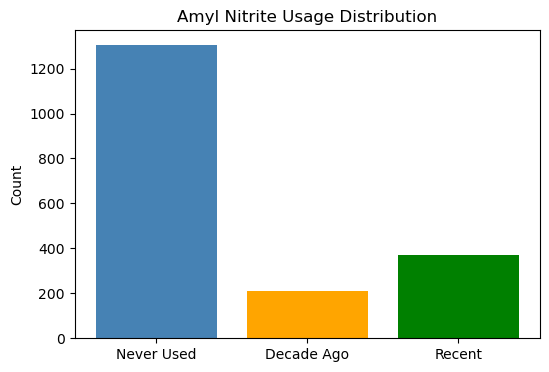

In [15]:
plt.figure(figsize=(6,4))
counts = df['Amyl'].value_counts().sort_index()
plt.bar(['Never Used', 'Decade Ago', 'Recent'], counts, color=['steelblue', 'orange', 'green'])
plt.title('Amyl Nitrite Usage Distribution')
plt.ylabel('Count')
plt.show()

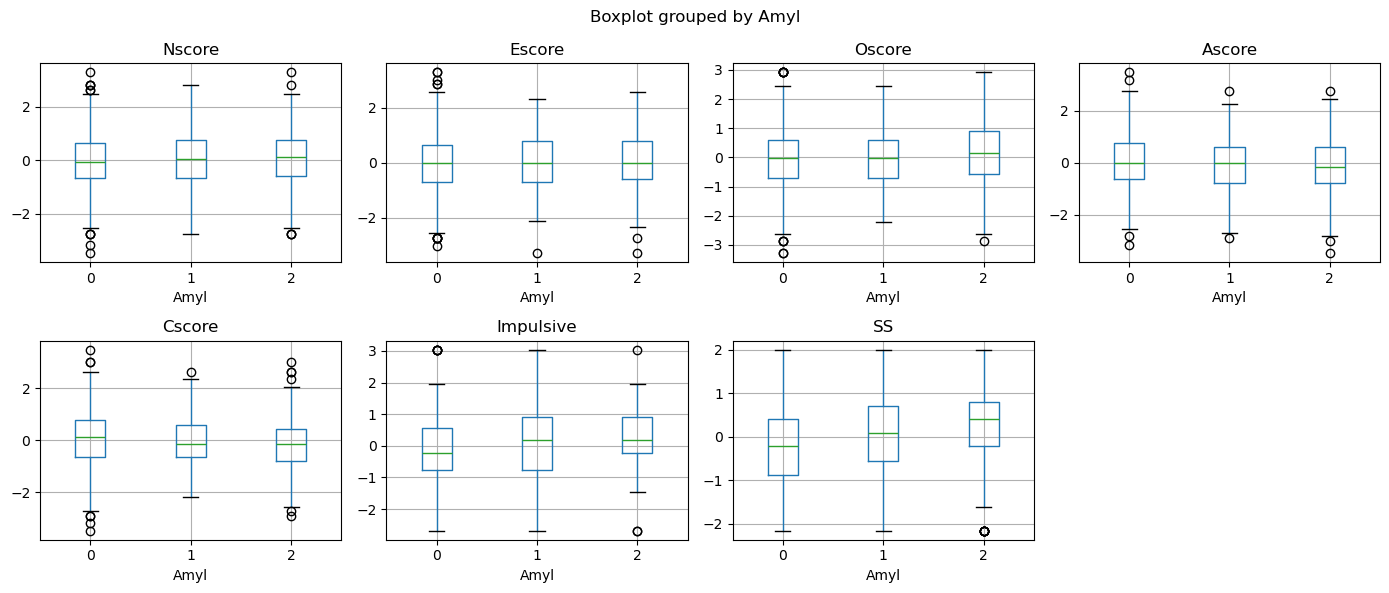

In [16]:
personality = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(personality):
    df.boxplot(column=col, by='Amyl', ax=axes[i])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()  

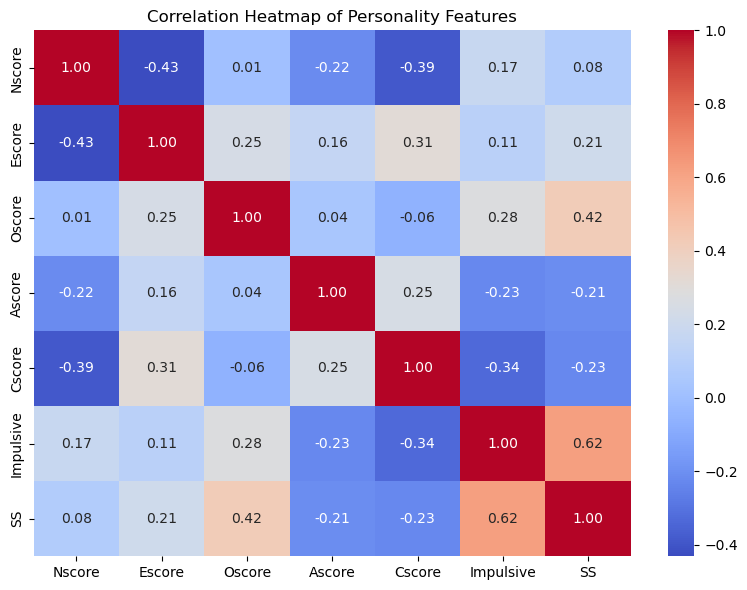

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[personality].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Personality Features')
plt.tight_layout()
plt.show()

In [21]:
df_raw = pd.read_csv('group_20.csv')
print(df_raw['Country'].value_counts().sort_index())

Country
-0.57009     557
-0.46841       5
-0.28519     118
-0.09765      54
 0.21128      20
 0.24923      87
 0.96082    1044
Name: count, dtype: int64


In [22]:
print(df['Country_raw'].value_counts().sort_index())

Country_raw
0     557
1       5
2     118
3      54
4      20
5      87
6    1044
Name: count, dtype: int64


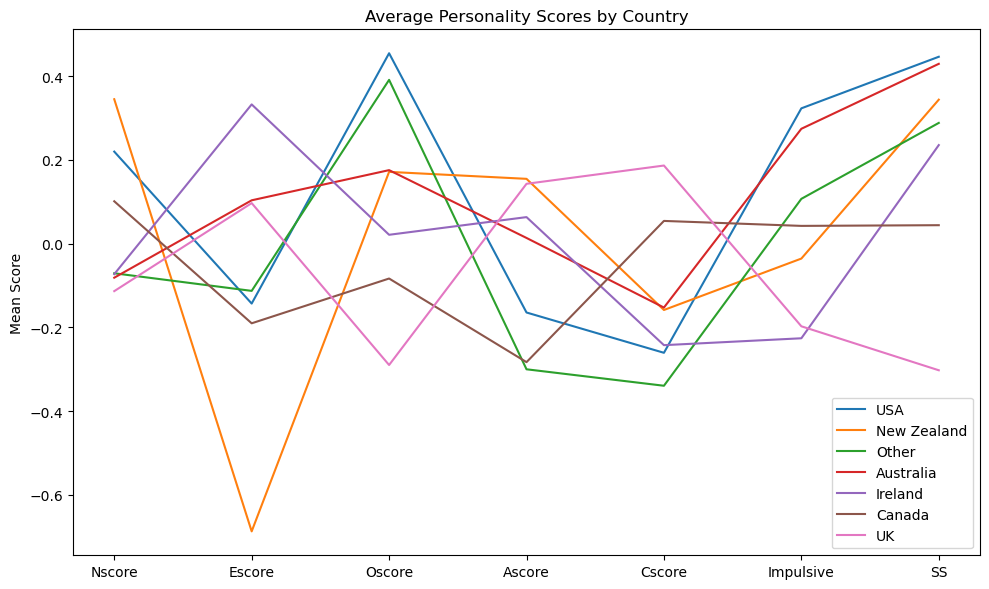

In [23]:
country_names = {0: 'USA', 1: 'New Zealand', 2: 'Other', 
                 3: 'Australia', 4: 'Ireland', 5: 'Canada', 6: 'UK'}
plt.figure(figsize=(10,6))
for code, name in country_names.items():
    subset = df[df['Country_raw'] == code]
    means = subset[personality].mean()
    plt.plot(personality, means, label=name)

plt.title('Average Personality Scores by Country')
plt.ylabel('Mean Score')
plt.legend()
plt.tight_layout()
plt.show()